In [1]:
filename = "/Users/halverso/data/EMIT-HLS-fusion-output/fused_mean_20240326.tif"

"/Users/halverso/data/EMIT-HLS-fusion-output/fused_mean_20240326.tif"

size(cube) = (202, 265, 212)


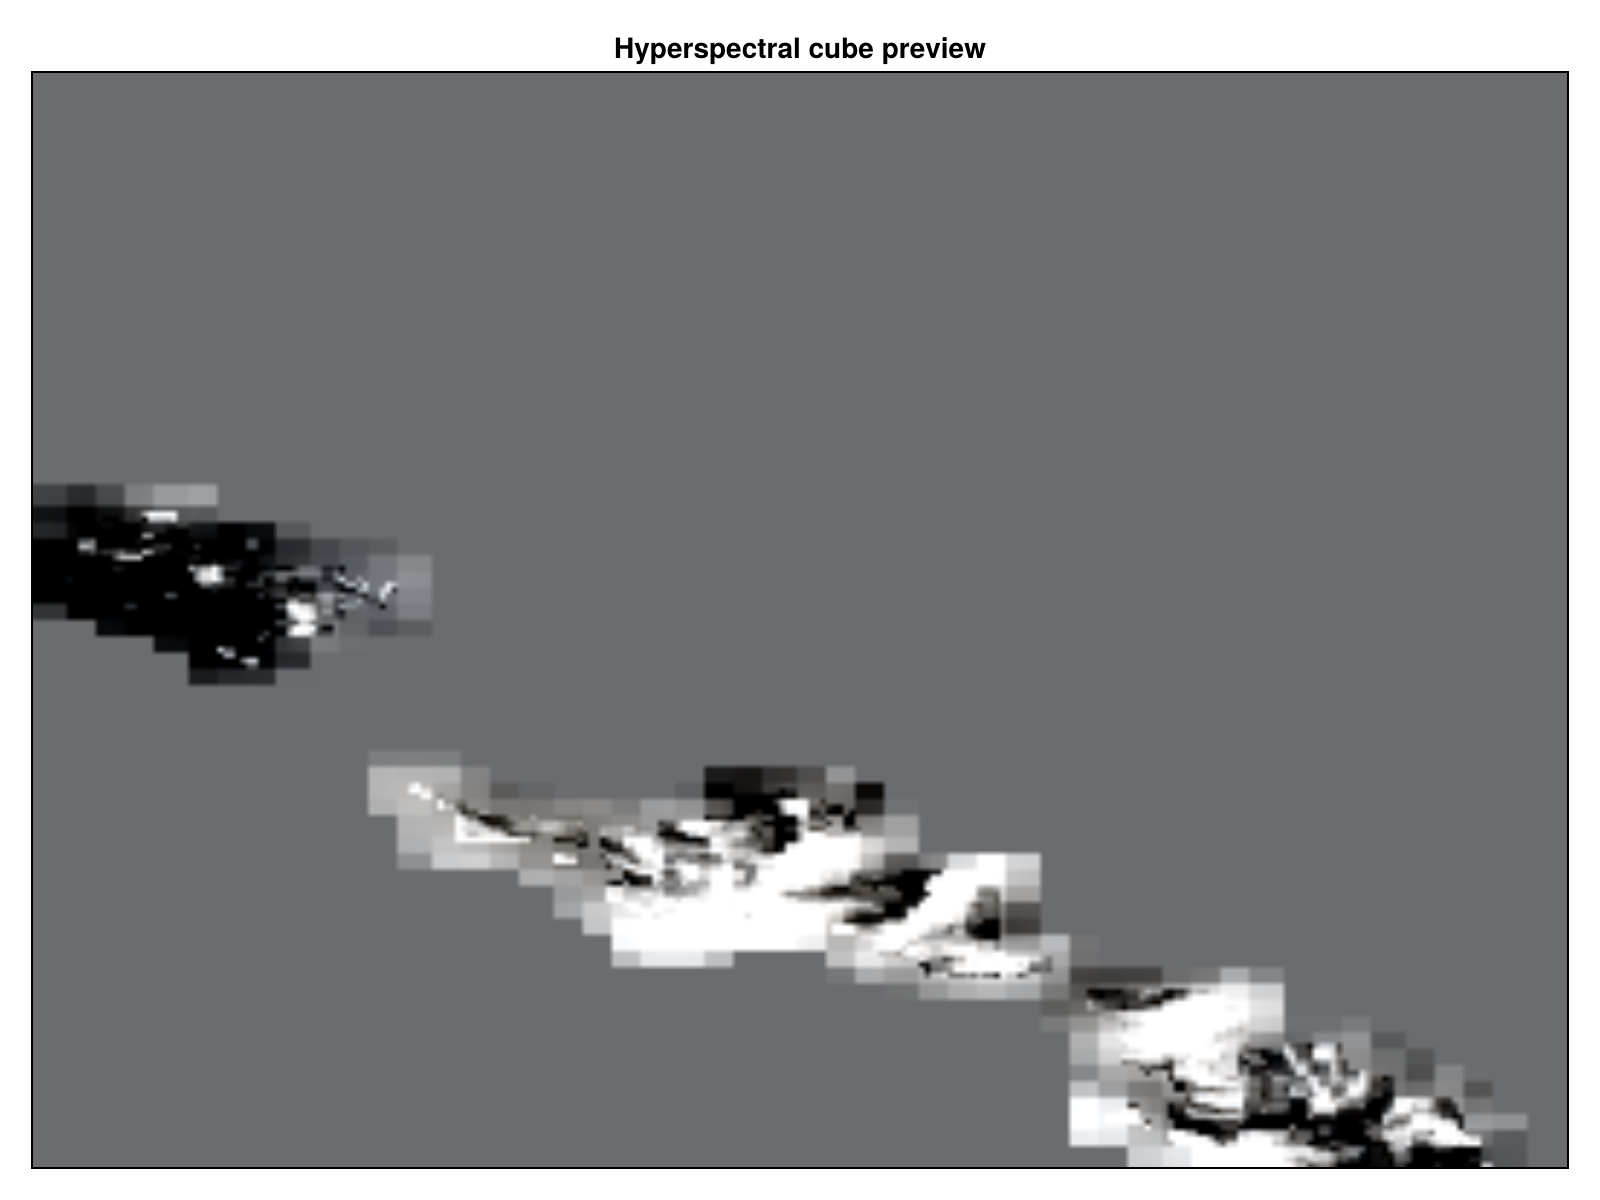

In [2]:
using ArchGDAL, Statistics, CairoMakie, Colors

stretch(x) = begin
    x = Float32.(x)
    vals = vec(x[isfinite.(x)])
    lo, hi = quantile(vals, (0.02, 0.98))
    clamp.((x .- lo) ./ max(hi - lo, eps(Float32)), 0, 1)
end

cube = ArchGDAL.read(filename) do ds
    nbands = ArchGDAL.nraster(ds)
    cat([Float32.(ArchGDAL.read(ArchGDAL.getband(ds, i))) for i in 1:nbands]...; dims=3)
end

@show size(cube)

b1, b2, b3 = size(cube, 3) >= 3 ? (1, 2, 3) : (1, 1, 1)

rgb = RGB.(
    stretch(cube[:, :, b1]),
    stretch(cube[:, :, b2]),
    stretch(cube[:, :, b3]),
)

fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1], title = "Hyperspectral cube preview")
image!(ax, permutedims(rgb, (2, 1)))
hidedecorations!(ax)
fig